# TP2: Kolmogorov         

In [ ]:
#Install package
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib

In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

 ============================================================
 
 ##  TP Kolmogorov                                                           

Goal : Show that for                                                                  
    $u(x,\mu)=tanh(\frac{x-\mu}{\delta}).$                                                                      
   the Kolmogorov $N$-width is not small for $N$ small      
    
============================================================

#### 1/ POD basis
Complete the codes that generate the training snapshots and compute the POD basis
with the function generate_translation_snapshots(Ne=400,x0=-100,x1=100,delta=0.001,n_mu=100) and Construct_RB(NumberOfSnapshots=100,Ne=100,NumberOfModes=80)

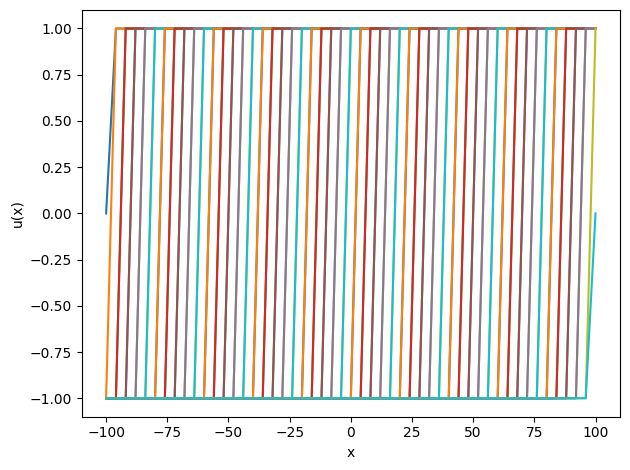

In [2]:
def generate_translation_snapshots(Ne=400,x0=-100,x1=100,delta=0.001,n_mu=100):
    """
    Ne+1 mesh elements
    mesh starting point x0
    mesh last point x1
    jump width: delta
    number of tested parameters n_mu<Ne
    """
    
    # fixed mesh
    x = ...

    # uniform mu
    # n_mu values between x0 and x1
    mu_values = ...

    snapshots = []

    for mu in mu_values:
        u = ...
        ...
    
    return np.array(snapshots), x, mu_values # should return snapshots, mesh, mu_values


## Test

snapshots,x,_=generate_translation_snapshots(Ne=50)
for u in snapshots:
    plt.plot(x,u)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.tight_layout()
plt.show()

In [3]:
""" OFFLINE """
""" POD """

def Construct_RB(NumberOfSnapshots=100,Ne=100,NumberOfModes=80):
    
    """
    Number of training parameters: NumberOfSnapshots
    Mesh size : Ne=100
    Number of basis functions: NumberOfModes
    """
    
    Snapshots,x,_=generate_translation_snapshots(Ne=Ne)
    NumberOfSnapshots=len(Snapshots)
    print("Number of snapshots:", NumberOfSnapshots)
    
    ## SVD ##
    # you can use (.,.)_l2 or the scaled scalar product 1./|Omega| * (.,.)_l2
    # indication : you can use the previous finite volume TP 
    
    # We first compute the correlation matrix C_ij = (u_i,u_j)_(l2)
    # Then, we compute the eigenvalues/eigenvectors of C 
    #SVD: C eigenVectors=eigenValues eigenVectors
    # sort the eigenvalues
    # retrieve N=NumberOfModes first eigenvalues
    ...
    
    print("eigenvalues: ",EigenValues)

    RIC=... #must be close to 0
    print("Relativ Information Content (must be close to 0): ",RIC)

    ReducedBasis = ...

    # orthogonality test
    """
    for i in range(NumberOfModes):
        MatVecProduct = L2.dot(ReducedBasis[i])
        for j in range(NumberOfModes):    
            test = np.dot(MatVecProduct, ReducedBasis[j])
            print("orthogonal:",test)
    """
    return ReducedBasis,Snapshots,EigenValues

Number of snapshots: 100
eigenvalues:  [2.06726211e+01 2.02661035e+01 2.29791699e+00 2.25344925e+00
 8.27950206e-01 8.12438142e-01 4.22970995e-01 4.15426425e-01
 2.56325200e-01 2.52048830e-01 1.71981580e-01 1.69349153e-01
 1.23483166e-01 1.21786418e-01 9.30657414e-02 9.19469955e-02
 7.27472761e-02 7.20066125e-02 5.85094558e-02 5.80265127e-02
 4.81504502e-02 4.78485303e-02 4.03817272e-02 4.02097090e-02
 3.44084876e-02 3.43310196e-02 2.97189006e-02 2.97107678e-02
 2.60140378e-02 2.59713021e-02 2.30103443e-02 2.29305724e-02
 2.05368857e-02 2.04306304e-02 1.84760506e-02 1.83514736e-02
 1.67411902e-02 1.66046566e-02 1.52673560e-02 1.51238405e-02
 1.40051121e-02 1.38584863e-02 1.29163068e-02 1.27695519e-02
 1.19711250e-02 1.18264962e-02 1.11459949e-02 1.10051560e-02
 1.04220806e-02 1.02862170e-02 9.78418052e-03 9.65409584e-03
 9.21991353e-03 9.09611195e-03 8.71911050e-03 8.60186645e-03
 8.27335499e-03 8.16277096e-03 7.87563276e-03 7.77168648e-03
 7.52006172e-03 7.42264389e-03 7.20168184e-03 

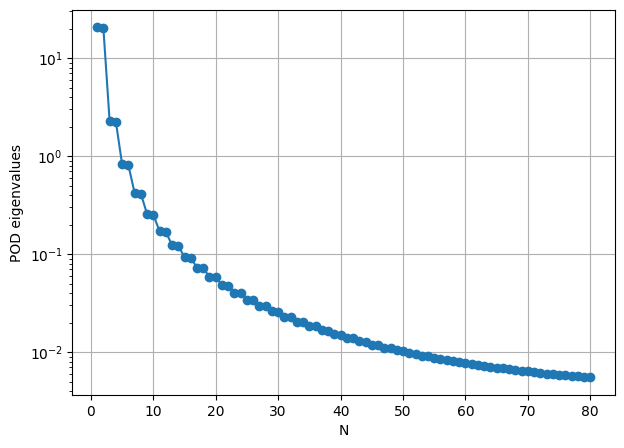

In [11]:
## L2 projection 
ReducedBasis,Snapshots,eigvals=Construct_RB(NumberOfSnapshots=80,Ne=100,NumberOfModes=80)

# POD eigenvalues
plt.figure(figsize=(7, 5))
plt.semilogy(np.arange(1, len(eigvals) + 1), eigvals, 'o-')
plt.xlabel("N")
plt.ylabel("POD eigenvalues")
plt.grid(True)
plt.show()

Number of snapshots: 100
eigenvalues:  [2.06726211e+01 2.02661035e+01 2.29791699e+00 2.25344925e+00
 8.27950206e-01 8.12438142e-01 4.22970995e-01 4.15426425e-01
 2.56325200e-01 2.52048830e-01 1.71981580e-01 1.69349153e-01
 1.23483166e-01 1.21786418e-01 9.30657414e-02 9.19469955e-02
 7.27472761e-02 7.20066125e-02 5.85094558e-02 5.80265127e-02
 4.81504502e-02 4.78485303e-02 4.03817272e-02 4.02097090e-02
 3.44084876e-02 3.43310196e-02 2.97189006e-02 2.97107678e-02
 2.60140378e-02 2.59713021e-02 2.30103443e-02 2.29305724e-02
 2.05368857e-02 2.04306304e-02 1.84760506e-02 1.83514736e-02
 1.67411902e-02 1.66046566e-02 1.52673560e-02 1.51238405e-02
 1.40051121e-02 1.38584863e-02 1.29163068e-02 1.27695519e-02
 1.19711250e-02 1.18264962e-02 1.11459949e-02 1.10051560e-02
 1.04220806e-02 1.02862170e-02 9.78418052e-03 9.65409584e-03
 9.21991353e-03 9.09611195e-03 8.71911050e-03 8.60186645e-03
 8.27335499e-03 8.16277096e-03 7.87563276e-03 7.77168648e-03
 7.52006172e-03 7.42264389e-03 7.20168184e-03 

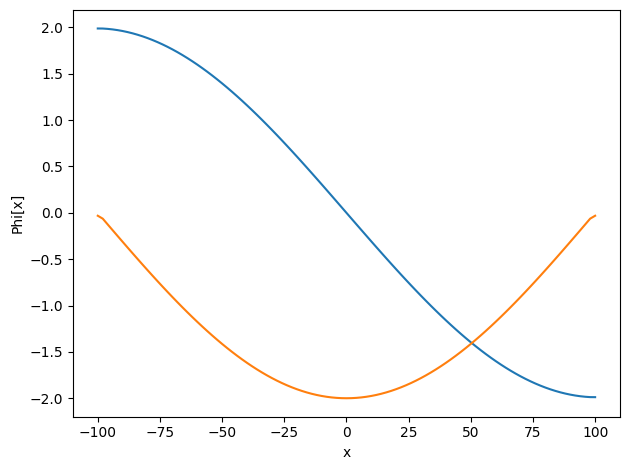

In [10]:
### test

ReducedBasis,Snapshots,eigvals=Construct_RB(NumberOfSnapshots=80,Ne=100,NumberOfModes=80)
x = np.linspace(-100, 100, 100 + 1)
plt.plot(x,ReducedBasis[0,:])
plt.plot(x,ReducedBasis[1,:])
plt.xlabel("x")
plt.ylabel("Phi[x]")
plt.tight_layout()
plt.show()

#### 2/ snapshot projection
Define a function project_snapshot(snapshot,x, ReducedBasis) computing the projection of a snapshot on $V_N$: for u in V, return $\sum_{i=1}^N \alpha_i \Phi_i$ where $\alpha_i = (u,\Phi_i)_{l2}$


In [12]:
def project_snapshot(snapshot,x, ReducedBasis):
    
    """
    l2 projection of a snapshot on V_N spanned by (Phi)_i
    Phi: shape (Ndofs, n)
    should return \sum_i alpha_i Phi_i where alpha_i = (u,Phi_i)_l2
    """
    ...
    return ...

#### 3/ Kolmogorov decay
Define a function compute_kolmogorov_decay(Snapshots, x,ReducedBasis) generating the error for a fixed $n$:
$d_{max}(n)= max_i \|u-P_n u\|_{l2} $ where $P_n u$ is the $l2$ projection.

Number of snapshots: 100
eigenvalues:  [2.06726211e+01 2.02661035e+01 2.29791699e+00 2.25344925e+00
 8.27950206e-01 8.12438142e-01 4.22970995e-01 4.15426425e-01
 2.56325200e-01 2.52048830e-01 1.71981580e-01 1.69349153e-01
 1.23483166e-01 1.21786418e-01 9.30657414e-02 9.19469955e-02
 7.27472761e-02 7.20066125e-02 5.85094558e-02 5.80265127e-02
 4.81504502e-02 4.78485303e-02 4.03817272e-02 4.02097090e-02
 3.44084876e-02 3.43310196e-02 2.97189006e-02 2.97107678e-02
 2.60140378e-02 2.59713021e-02 2.30103443e-02 2.29305724e-02
 2.05368857e-02 2.04306304e-02 1.84760506e-02 1.83514736e-02
 1.67411902e-02 1.66046566e-02 1.52673560e-02 1.51238405e-02]
Relativ Information Content (must be close to 0):  0.008628015526132127
Slope ~ n^(alpha) : alpha = -0.569


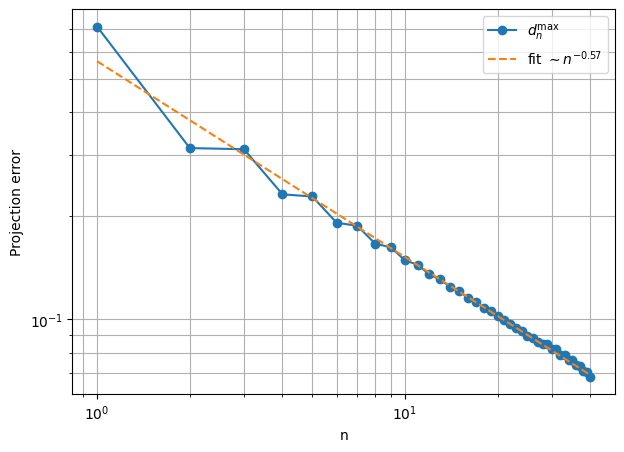

In [18]:
def compute_kolmogorov_decay(Snapshots, x,ReducedBasis):
 
    """
    Snapshots : array of snapshots
    x: mesh
    ReducedBasis: basis functions
    """
    NumberOfSnapshots, Ndofs = Snapshots.shape
    NumberOfModes = ReducedBasis.shape[0]
    #print(np.shape(ReducedBasis))
    
    dmax = np.zeros(NumberOfModes)

    for n in range(1, NumberOfModes + 1): #forloop over n= 1 ... N
        ReducedBasis_n = ...  # shape (Ndofs, n)

        errs = []
        for i in range(NumberOfSnapshots): #for each snapshots
            ...
            # compute the error ||u-P_Nu||_l2
            err_l2 = ...
            errs.append(err_l2)

        errs = np.array(errs)
        
        dmax[n - 1] = np.max(errs)

    return dmax


# -------------------------
# Test
# -------------------------
NumberOfSnapshots = 80
Ne = 100
NumberOfModes = 40

ReducedBasis,Snapshots,_= Construct_RB(NumberOfSnapshots=NumberOfSnapshots,Ne=Ne,NumberOfModes=NumberOfModes)

x0=-100
x1=100
x = np.linspace(x0, x1, Ne + 1)
dmax = compute_kolmogorov_decay(Snapshots,x, ReducedBasis)

# log-log estimation of the slope
nvals = np.arange(1, len(dmax) + 1)

#Use np.polyfit(x,y,deg) to fit a polynomial p[0] * x + p[1] to points (nvals, dmax ) in log scale
#
coef = ...
alpha = ...
print(f"Slope ~ n^(alpha) : alpha = {alpha:.3f}")

# Plot
plt.figure(figsize=(7, 5))
plt.loglog(nvals, dmax, 'o-', label=r'$d_n^{\max}$')

plt.loglog(nvals,np.exp(coef[1]) * nvals**coef[0],  '--',label=fr'fit $\sim n^{{{alpha:.2f}}}$')
plt.xlabel("n")
plt.ylabel("Projection error")
plt.grid(True, which="both")
plt.legend()
plt.show()

